## Q1 Fragment Length frequency + Rescaling

### Fragment Length Frequency
Q- You are given a file (see link below) with each line indicating where a DNA fragment has mapped on the chromosome. Your goal is to count individual fragment lengths, and then normalize it by the total count of all fragment lengths. Once you have the normalized count, you will plot that using plotting packages in Python. X-axis will be fragment length (unit: base pairs) and Y-axis will be labelled "Narmalized Frequency [A.U.]". Fragment length can simply be calculated by subtracting 2nd column from the 3rd.

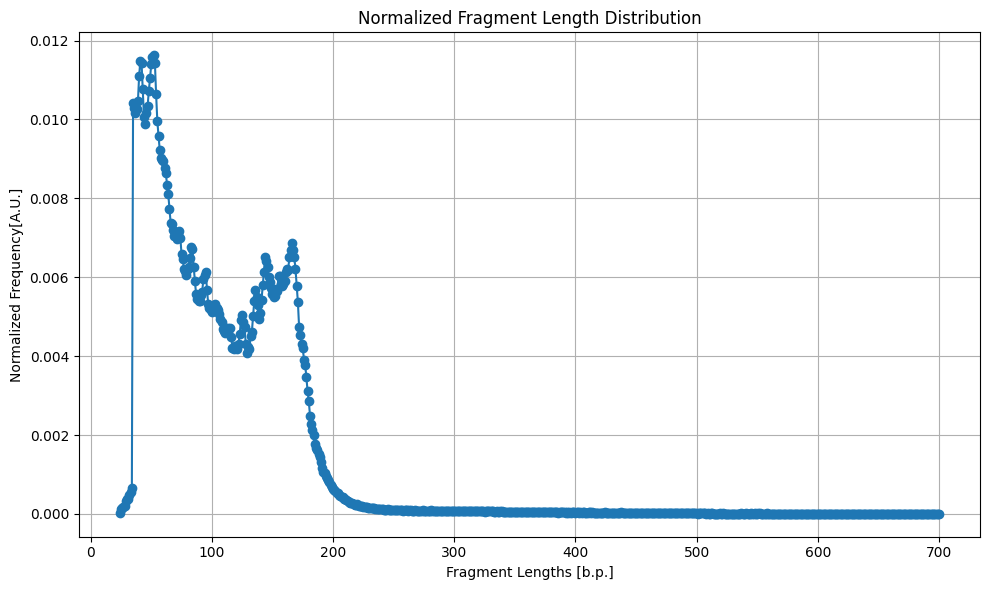

In [2]:
from matplotlib import pyplot as plt
import gzip

# Initializing dictionary to store the frequency of each fragment lengths
freq = {}

# Reading the given query.bed file to extract the data into the dictionary 'freq'
with gzip.open("query.bed.gz", "rt") as file:
    for line in file:
        cols = line.strip().split()  # Reading the line into cols as list of strings
        if len(cols) >= 3:
            # Although the 4th column of the file directly gives the length of the fragment but since it is mentioned in question to calculate it by subtracting 2nd column from the 3rd so I am doing it this way
            s = int(cols[1]) # starting position
            e = int(cols[2]) # ending position
            length = e - s # Length of the fragment
            # Logic to add in dictionary or increase the frequency
            if length > 0:
                if length in freq:
                    freq[length] += 1
                else:
                    freq[length] = 1

# Calculating the normalized frequency values by diving each frequency with the total sum of all frequencies

total=0
for i in freq.values():
    total+=i

normalized_freqs={}
for length,count in freq.items():
    normalized_freqs[length]=count/total

# Sorting the lengths to display in ascending order in the graph on X-axis
sorted_lengths = sorted(normalized_freqs.keys())
# Correspoding frequencies of the sorted lengths
sorted_freqs = [normalized_freqs[length] for length in sorted_lengths]

# Plotting it using pyplot from matplotlib library
plt.figure(figsize=(10, 6))
plt.plot(sorted_lengths, sorted_freqs, marker='o', linestyle='-')
plt.xlabel("Fragment Lengths [b.p.]")
plt.ylabel("Normalized Frequency[A.U.]")
plt.title("Normalized Fragment Length Distribution")
plt.grid()
plt.tight_layout()

plt.show()

The workflow of the code begins by reading the `query.bed` file to calculate fragment lengths by subtracting the start position from the end position. The frequencies of each fragment length are then counted and stored in a dictionary. Subsequently, the total frequency is calculated, and each fragment length's frequency is normalized by dividing it by the total. To ensure proper visualization, the fragment lengths are sorted in ascending order. Finally, the normalized frequency distribution is plotted using `matplotlib`, with fragment lengths on the X-axis and normalized frequencies on the Y-axis.


### Rescaling
Q- Often, you will received two sets of data with differnt emperical distribution. The goal is to rescale one (query) to the other (reference). In this part, you will write codes to achieve this. You are given a reference distribution (reference.hist) and a query bed file (query.bed.gz). You have to rescale (subsample the data) so that when you draw the normalized frequency, it should almost match the reference.

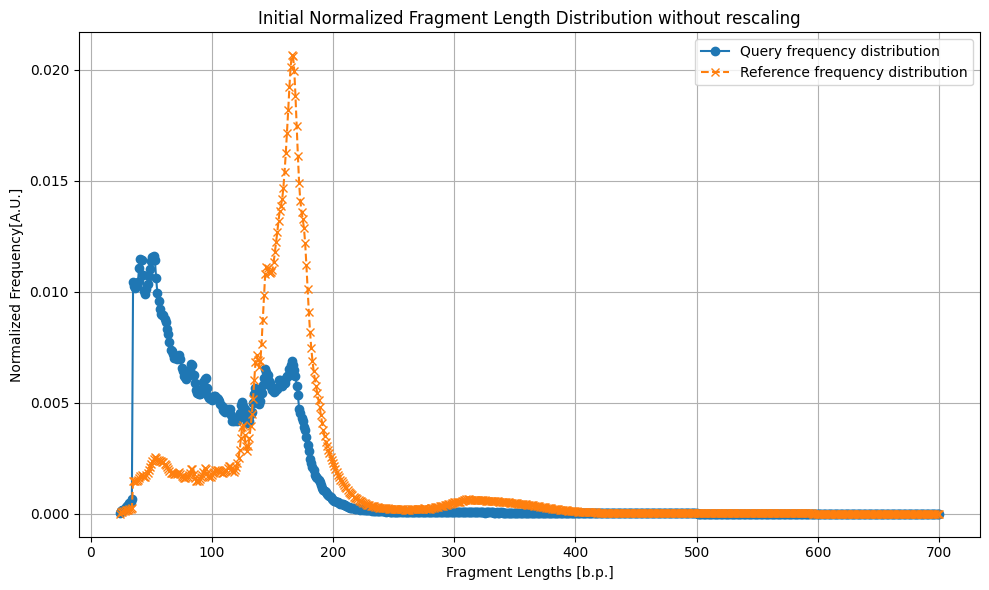

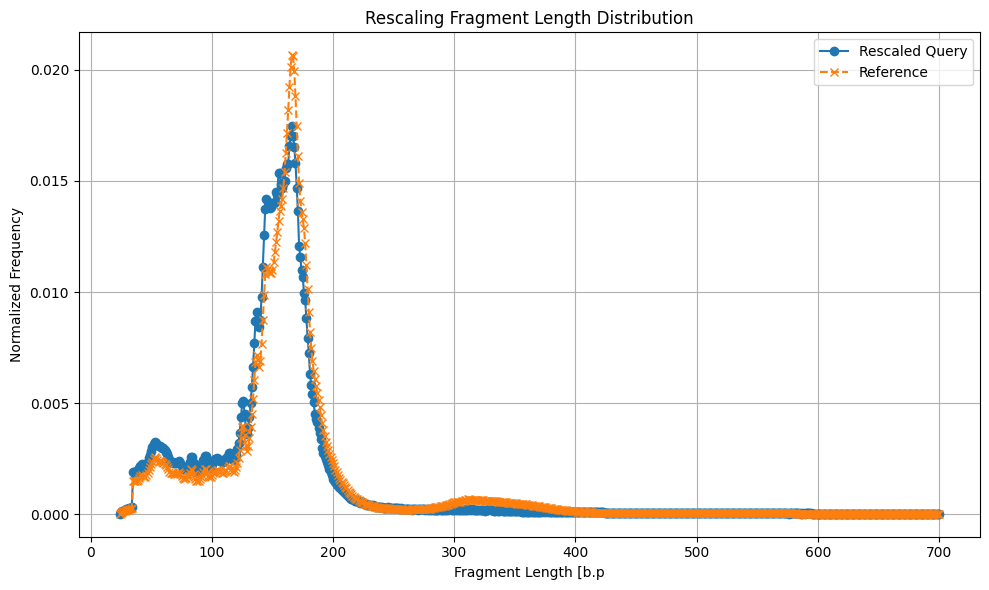

In [3]:
import random

# Dictionary to store the frequency of each length
reference_hist = {}

# Loading the reference distribution from given reference.hist file
with open("reference.hist", "r") as ref_file:
    for line in ref_file:
        p = line.strip().split()
        if len(p) >= 2: # Checking if the line is valid or not so that the program handles invalid lines as well by ignoring them
            length = int(p[0]) # Lengths
            freq = float(p[1]) # Frequencies of the corresponding length
            reference_hist[length] = freq # Adding the frequencies of reference in the dictionary reference_hist

# Normalizing the frequecnies as in 1st part
total_ref=0
for i in reference_hist.values():
    total_ref+=i
# normalized_ref dictionary contains the normalized frequncies
normalized_ref={}
for i,j in reference_hist.items():
    normalized_ref[i]=j/total_ref

# Loading the query.bed file
query_fragments = {}

with gzip.open("query.bed.gz", "rt") as qf:
    for l in qf:
        p = l.strip().split()
        if len(p) >= 3:
            s = int(p[1]) # Starting positon
            e = int(p[2]) # Ending postion
            length = e-s # Length
            if length > 0:
                if length not in query_fragments:
                    query_fragments[length] = []
                query_fragments[length].append(l)

# Plotting initially without rescaling
plt.figure(figsize=(10, 6))
plt.plot(sorted_lengths, sorted_freqs,label="Query frequency distribution", marker='o', linestyle='-')
x_ref_hist=sorted(normalized_ref.keys())
y_ref_hist=[normalized_ref[x] for x in x_ref_hist]
plt.plot(x_ref_hist,y_ref_hist,label="Reference frequency distribution",marker='x',linestyle='--')
plt.xlabel("Fragment Lengths [b.p.]")
plt.ylabel("Normalized Frequency[A.U.]")
plt.title("Initial Normalized Fragment Length Distribution without rescaling")
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

# Rescaling:-

# Subsampling every query fragments to match reference distribution
rescaled_fragments = []

# Determinig how many total samples to keep in the subsamples:
query_total=0
for i in query_fragments.values():
    query_total+=len(i)
# Since after subsampling the total numer of fragments will be less
# than query_total (currently total number of fragments) so we should
# take a smaller number of fragments as total for rescaling (like I have taken 50% here)
rescale_total = int(query_total * 0.5)

for length, prob in normalized_ref.items():
    if length in query_fragments:
      # Let sample_count be the number of fragments of current length (in this iteration of loop)
      # based on reference upto which it should be sampled
        sample_count = int(prob * rescale_total)
        frags = query_fragments[length] # frags contains the actual number of fragments of current length in the query

      # Logic for subsampling:-
      # If the frequncy of fragments is less in the query than the sample_count then take all
      # otherwise take sample_count number of random samples (subsampling)
        if len(frags) <= sample_count:
            rescaled_fragments.extend(frags)
        else:
            rescaled_fragments.extend(random.sample(frags, sample_count))

# Count new distribution from rescaled_fragments
rescaled_counts = {} # Dictionary to store the frequencies of rescaled distribution
for line in rescaled_fragments:
    p = line.split()
    start = int(p[1])
    end = int(p[2])
    length = end - start
    if length in rescaled_counts:
        rescaled_counts[length] += 1
    else:
        rescaled_counts[length] = 1

total_rescaled=0
for i in rescaled_counts.values():
    total_rescaled+=i
# print(total_rescaled,rescale_total) # debugging
# Normalizing the rescaled_frequencies
normalized_rescaled_distribution={}
for i,j in rescaled_counts.items():
    normalized_rescaled_distribution[i]=j/total_rescaled

# Plotting
plt.figure(figsize=(10, 6))
# Rescale
x_rescaled = sorted(normalized_rescaled_distribution.keys())
y_rescaled = [normalized_rescaled_distribution[x] for x in x_rescaled]
plt.plot(x_rescaled, y_rescaled, label="Rescaled Query", linestyle='-', marker='o')

# Reference
x_ref = sorted(normalized_ref.keys())
y_ref = [normalized_ref[x] for x in x_ref]
plt.plot(x_ref, y_ref, label="Reference", linestyle='--', marker='x')

plt.xlabel("Fragment Length [b.p")
plt.ylabel("Normalized Frequency")
plt.title("Rescaling Fragment Length Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The workflow of the code begins by reading the `reference.hist` file to extract fragment lengths and their frequencies, which are stored in the dictionary `reference_hist`. These frequencies are then normalized by dividing each frequency by the total sum of all frequencies, resulting in the dictionary `normalized_ref`. Next, the `query.bed` file is read to calculate fragment lengths by subtracting the start position from the end position. These fragments are grouped by their lengths and stored in the dictionary `query_fragments`. The initial normalized frequency distribution of the query data is plotted alongside the reference distribution for comparison before rescaling. The total number of fragments in the query data is calculated, and a target number of fragments for rescaling is determined. For each fragment length, the number of fragments to sample is calculated based on the reference distribution's normalized frequency. Subsampling is performed by either taking all fragments if the query has fewer fragments than required or randomly sampling the required number of fragments. The rescaled fragments are then used to calculate the frequency of each fragment length, which is normalized to create the `normalized_rescaled_distribution`. Finally, the normalized frequency distribution of the rescaled query data is plotted alongside the reference distribution to demonstrate alignment after rescaling.